In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

In [2]:
#obverse the dataframe
df = pd.read_csv('C:\\Users\\吉吉\\.cache\\kagglehub\\datasets\\aminasalamt\\supply-chain-analysis-dataset\\versions\\1\\supply_chain_data.csv')
title = df.head()
#df.info()
describe = df.describe()
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())


Dataset shape: (100, 24)
Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


In [3]:
#check missing value
missing_values = df.isnull().sum()
print('missing_values')
print(missing_values)
#check duplicate lines
duplicate_lines = df.duplicated().sum()
print('duplicate_lines')
print(duplicate_lines)

missing_values
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64
duplicate_lines
0


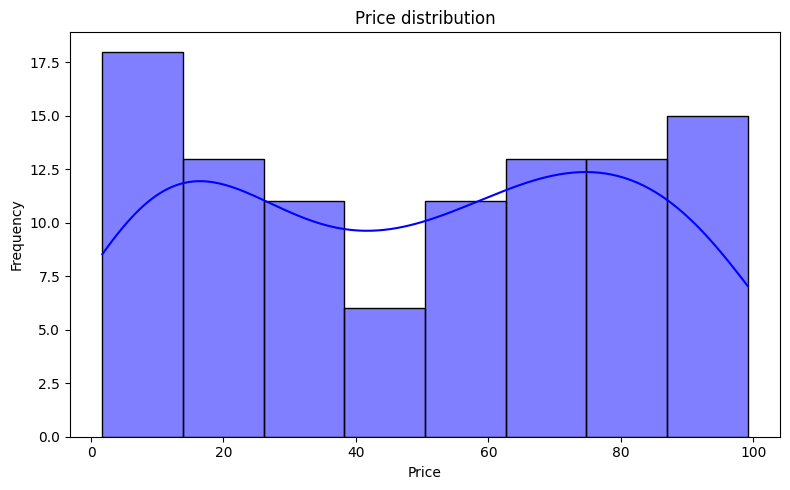

In [4]:
#Plot Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title("Price distribution")
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


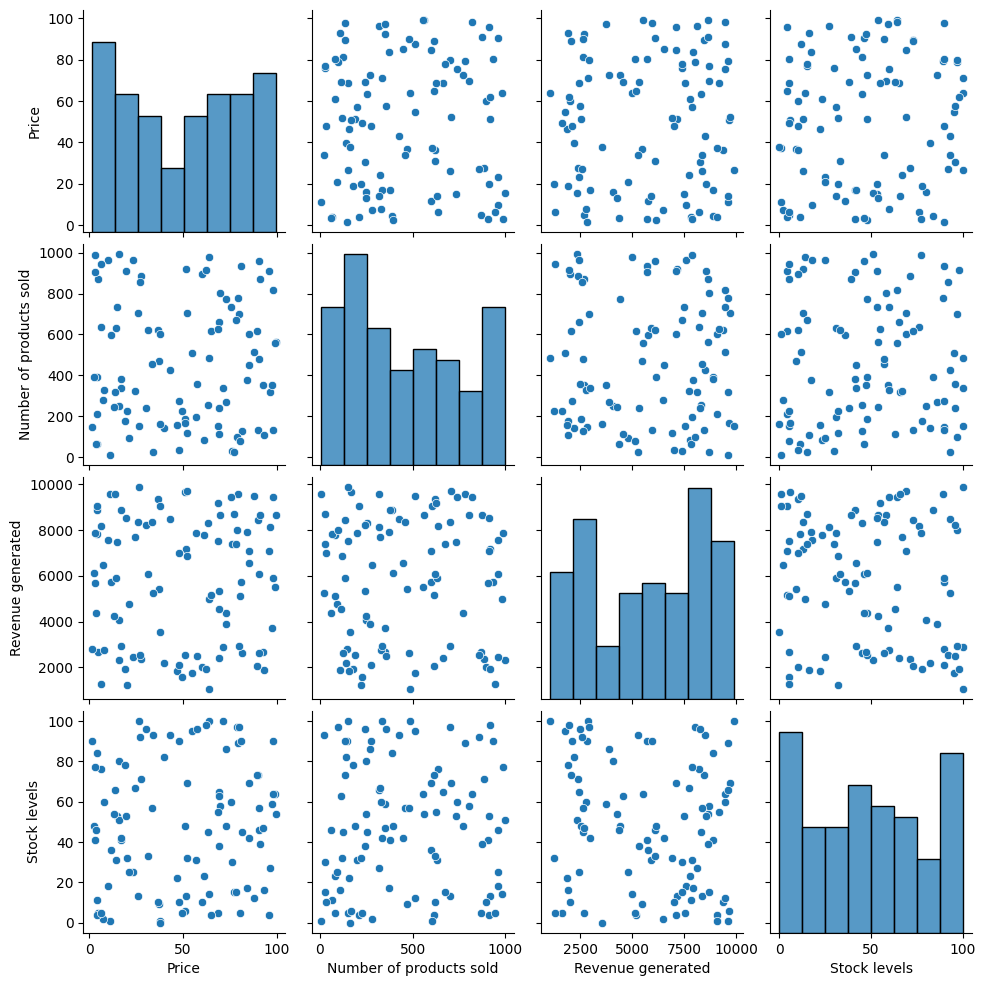

In [5]:
#Pair Plot
selected_cols = ['Price', 'Number of products sold', 'Revenue generated', 'Stock levels']
sns.pairplot(df[selected_cols])

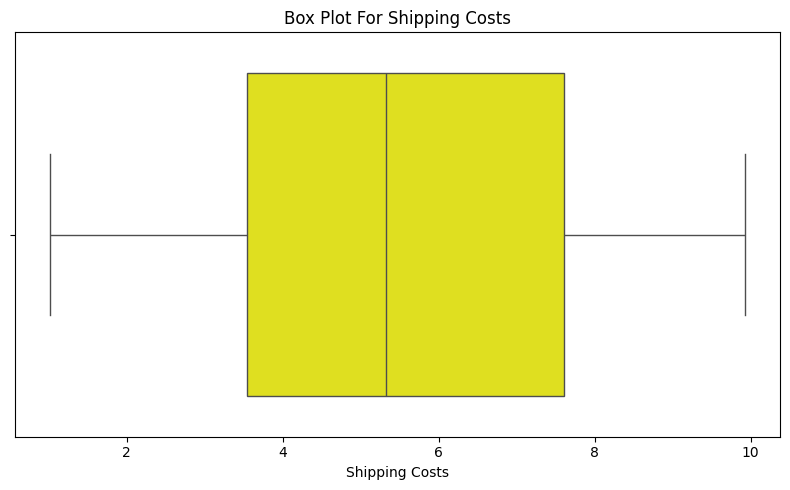

In [6]:
#Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Shipping costs'], color='yellow')
plt.title("Box Plot For Shipping Costs")
plt.xlabel("Shipping Costs")
plt.tight_layout()
plt.show()

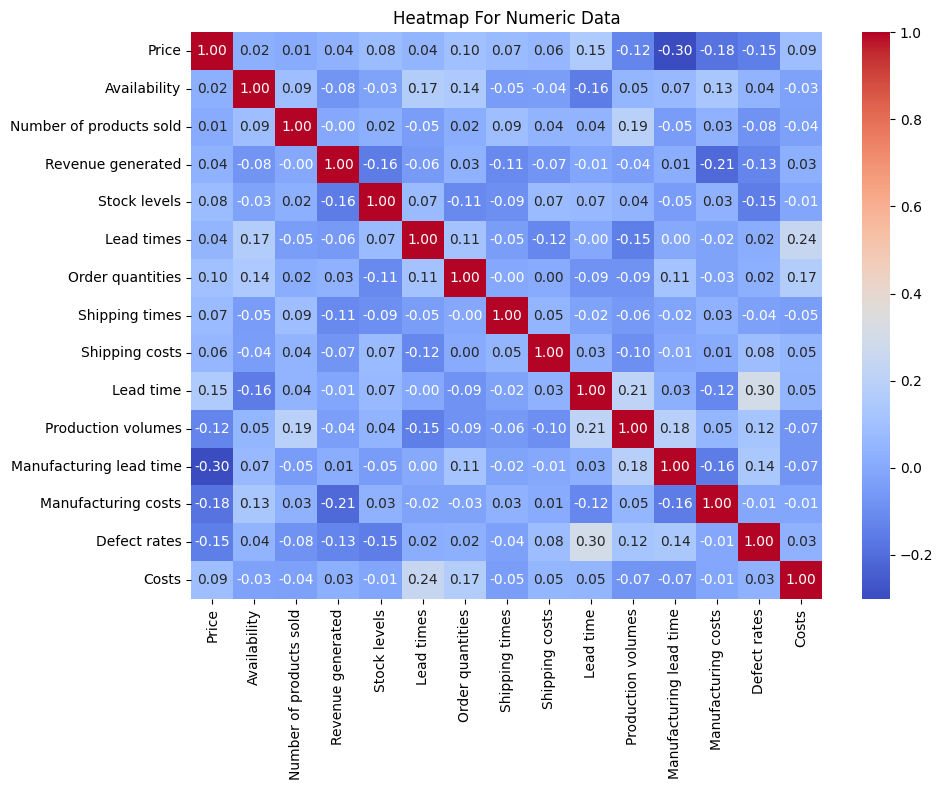

In [7]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include = [np.number])
if numeric_df.shape[1] >= 10:
    plt.figure(figsize = (10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Heatmap For Numeric Data')
    plt.tight_layout()
    plt.show()
else:
    print('Not Enough Numeric colum for Heatmap')

    

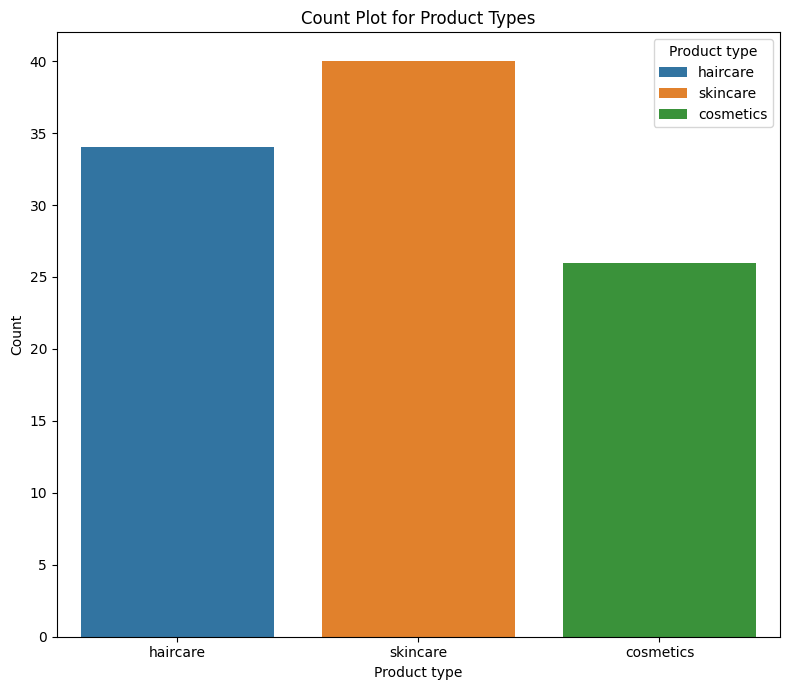

In [8]:
#Count Plot for Product Type
plt.figure(figsize = (8, 7))
sns.countplot(data = df, x = 'Product type', hue='Product type', legend=True)
plt.title('Count Plot for Product Types')
plt.xlabel('Product type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
#make prediction
target = 'Revenue generated' 
numeric_features = numeric_df.columns.tolist()
if target in numeric_features:
    numeric_features.remove(target)
categorical_features = ['Product type', 'Shipping carriers', 'Supplier name', 'Location', 'Transportation modes']

x = df[numeric_features + categorical_features]
y = df[target]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

feature_names = (numeric_features + 
                list(model.named_steps['preprocessor']
                    .named_transformers_['cat']
                    .get_feature_names_out(categorical_features)))

coefficients = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.head(15))

R² Score: -1.247
MAE: 3632.28
RMSE: 4249.60
                        Feature  Coefficient
17  Shipping carriers_Carrier C  1055.703482
9            Production volumes   671.198687
27    Transportation modes_Road   621.865361
21     Supplier name_Supplier 5   585.411408
2       Number of products sold   421.409664
7                Shipping costs   404.361682
8                     Lead time   337.059183
26    Transportation modes_Rail   314.088760
20     Supplier name_Supplier 4   254.005739
4                    Lead times   208.459111
5              Order quantities    -0.876813
10      Manufacturing lead time   -34.538752
13                        Costs  -263.833885
6                Shipping times  -347.231561
0                         Price  -348.888127


<function matplotlib.pyplot.show(close=None, block=None)>

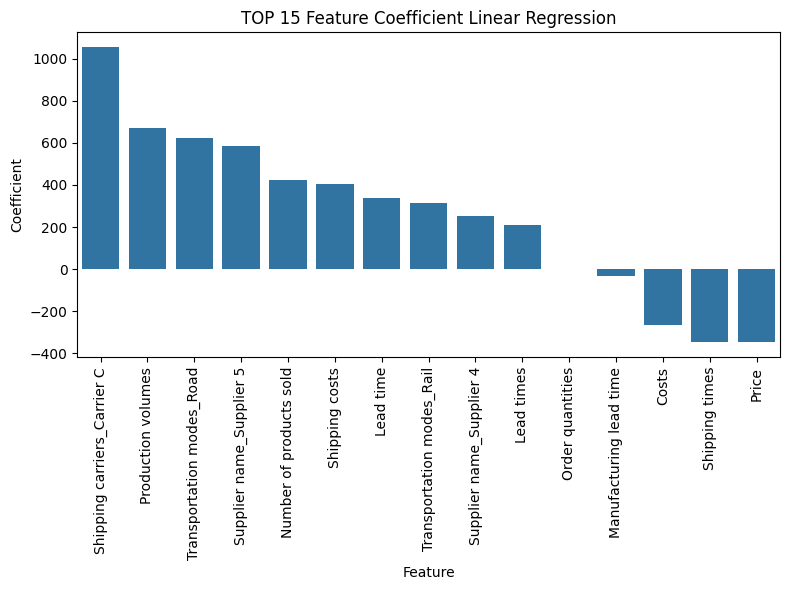

In [10]:
plt.figure(figsize = (8, 6))
sns.barplot(data = coef_df.head(15), x = 'Feature', y = 'Coefficient')
plt.xticks(rotation=90)
plt.title('TOP 15 Feature Coefficient Linear Regression')
plt.tight_layout()
plt.show

In [11]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators = 100, random_state = 45))
                ])
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: -0.191
MAE: 2748.05
RMSE: 3093.66
